# Hotel Dataset — Task 2 on data cleaning, Matplotlib + Seaborn

1. Remove leading/trailing spaces from column names
Explanation: Column names like "Booking ID " and "Customer Name" have extra spaces. This
causes errors when you try to select columns. Just strip the spaces so names become clean
(Booking ID, Customer Name).

In [68]:
import pandas as pd
import numpy as np
import re

In [69]:
# Read the data set
df= pd.read_csv (r"D:\Poonam Docs\Naresh it files\Datasets\Hotel_booking_dataset - Hotel_booking_dataset.csv")


In [70]:
# Remove leading/triling space from column names
df.columns = (df.columns.str.strip().str.replace(r"\s+", " ", regex=True))


2. Standardize all date formats into one consistent format (YYYY-MM-DD)
Explanation: Dates appear as 2025-05-17 00:00:00, 2025/02/20, 15/01/2025, and even
invalid ones like 32/13/2025. Convert everything to a single clean format and turn bad dates
into missing values.

In [71]:
# Standardize all date formats into one consistent format (YYYY-MM-DD)
def clean_date(x):
    if pd.isna(x):
        return pd.NaT
        formats = ["%Y-%m-%d %H:%M:%S","%Y-%m-%d","%Y/%m/%d","%d/%m/%Y"]
        for fmt in formats:
            try:
                return pd.to_datetime(x,format=fmt)
            except:
                pass
            return pd.NaT

df["Booking Date"] = df["Booking Date"].apply(clean_date)
df["Booking Date"]=df["Booking Date"].dt.strftime("%Y/%m/%d")


3. Handle completely missing Customer Name values
Explanation: Some rows have blank Customer Name or values like N/A. Decide whether to
fill them with a placeholder (e.g., “Unknown”) or drop those rows, depending on whether
the name is critical for analysis.

In [72]:
# Handle completely missing Customer Name values
missing_name_values=["","N/A","NA","Null","None"]
df["Custmoer Name"] =(df["Customer Name"].replace(missing_name_values,np.nan).fillna("unknown"))


4. Fix inconsistent Gender values
Explanation: Gender appears as Male, FEMALE, male, F, M, Other, etc. Convert everything to
a standard set such as Male, Female, Other.

In [73]:
#Fix inconsistent Gender values
gender_mapping ={"male":"Male","M":"Male","female":"Female","f":"Female","other":"Other"}
                 
df["Gender"] =df["Gender"].astype("string").str.strip().str.lower().map(gender_mapping).fillna("Unknow")


5. Clean and standardize City names
Explanation: Cities have typos and casing issues (mumbai, Mumbai , Bangalore, Hydrabad,
blank). Correct spelling, remove extra spaces, and make casing consistent (e.g., Title Case).

In [74]:
# Clean and standardize City names
City_mapping={"mumbai":"Mumbai",
              "delhi":"Delhi",
              "pune":"Pune",
              "chennai":"Chennai",
              "hydrabad":"Hyderabad",
              "hyderabad":"Hyderabad",
              "benglore":"Bengaluru",
              "bengaluru":"Bengaluru"}
df["City"] = (df["City"].astype("string").str.strip().str.lower().map(City_mapping).fillna("Unknow"))


6. Standardize Room Type categories
Explanation: Room Type has Suite, Deluxe, delux, standard, exec, Unknown, and blanks.
Map similar values to a clean list: Standard, Deluxe, Suite, Executive.

In [75]:
# Standardize Room Type categories
room_type_mapping = {
    "standard": "Standard",
    "std": "Standard",
    "deluxe": "Deluxe",
    "delux": "Deluxe",
    "dlx": "Deluxe",
    "suite": "Suite",
    "executive": "Executive",
    "exec": "Executive",
    "unknown": "Unknown"}

df["Room Type"] = (df["Room Type"].astype("string").str.strip().str.lower().map(room_type_mapping).fillna("Unknown"))


7. Clean Booking Channel values
Explanation: Values include Online, online, Walk-in, Travel Agent, TravelAgent, corp,
Corporate. Unify them into a small consistent set (Online, Walk-in, Corporate, Travel Agent).

In [76]:
#Clean Booking Channel values
channel_mapping = {
    "online": "Online",
    "walk-in": "Walk-in",
    "walk in": "Walk-in",
    "walkin": "Walk-in",
    "travel agent": "Travel Agent",
    "travelagent": "Travel Agent",
    "corporate": "Corporate",
    "corp": "Corporate"}

df["Booking Channel"] = (df["Booking Channel"].astype("string").str.strip().str.lower().map(channel_mapping))



8. Standardize Customer Segment
Explanation: Segments appear as Premium, regular, REG, Budget , VIP, etc. Create a clean set
such as Budget, Regular, Premium, Corporate, VIP and map everything to it.

In [77]:
segment_mapping = {
    "budget": "Budget",
    "regular": "Regular",
    "reg": "Regular",
    "premium": "Premium",
    "corporate": "Corporate",
    "corp": "Corporate",
    "vip": "VIP"}

df["Customer Segment"] = (df["Customer Segment"].astype("string").str.strip().str.lower().map(segment_mapping))


9. Fix Age column (invalid and non-numeric values)
Explanation: Age has numbers, blanks, 30 yrs, 25 years, 45Y, and impossible values like 150
or 100. Extract the number, convert to integer, and set unrealistic ages (e.g., <18 or >100) to
missing.

In [78]:
#Fix Age column (invalid and non-numeric values)
def extract_numeric(value):
    if pd.isna(value):
        return np.nan

    match = re.search(r"-?\d+(?:\.\d+)?", str(value))

    if match:
        return float(match.group())

    return np.nan


df["Age"] = df["Age"].apply(extract_numeric)

df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce")

df["Age"] = df["Age"].where(
    df["Age"].between(18, 90))

df["Age"] = df["Age"].round().astype("Int64")


10. Clean Room Nights column
Explanation: Values include numbers, N/A, 3 nights, 100, 30. Extract only the numeric part,
convert to integer, and decide what to do with extreme values (e.g., 100 nights).

In [79]:
# Clean Room Nights column
df["Room Nights"] = df["Room Nights"].apply(extract_numeric)

df["Room Nights"] = pd.to_numeric(
    df["Room Nights"],
    errors="coerce")

df["Room_Nights_Outlier"] = (
    df["Room Nights"] > 30)

df.loc[
    df["Room Nights"] > 30,
    "Room Nights"] = np.nan

df["Room Nights"] = df["Room Nights"].astype("Int64")

11. Fix Room Rate (mixed formats and extreme values)
Explanation: Room Rate contains normal numbers, 15k, $8000, 12000 INR, 100000, 250000,
and blanks. Convert text formats to numbers, remove currency symbols, and flag or handle
unrealistic rates.

In [80]:
#Fix Room Rate (mixed formats and extreme values)
def clean_currency(value):

    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    if text in ["", "na", "n/a", "none", "unknown"]:
        return np.nan

    text = text.replace(",", "")

    multiplier = 1

    if text.endswith("k"):
        multiplier = 1000
        text = text[:-1]

    numeric_part = re.sub(
        r"[^0-9.\-]",
        "",
        text)

    try:
        return float(numeric_part) * multiplier
    except ValueError:
        return np.nan


df["Room Rate"] = df["Room Rate"].apply(clean_currency)

df["Room_Rate_Outlier"] = (
    (df["Room Rate"] <= 0) |
    (df["Room Rate"] > 50000))

df.loc[
    df["Room_Rate_Outlier"],
    "Room Rate"] = np.nan

12. Clean Discount % column
Explanation: Discount has numbers, none, 10%, 5 %, N/A, and impossible values like 120.
Convert everything to a pure number between 0 and 100; treat “none” as 0 and values >100
as missing or capped.

In [81]:
#Clean Discount % column
def clean_percentage(value):

    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    if text in ["none", "no", "nil"]:
        return 0.0

    text = text.replace("%", "").strip()

    try:
        value = float(text)
    except ValueError:
        return np.nan

    if 0 <= value <= 100:
        return value

    return np.nan


df["Discount %"] = df["Discount %"].apply(clean_percentage)

13. Handle missing and invalid Rating values
Explanation: Rating has numbers, blanks, 5/5, 4 stars, and values above 5 (e.g., 6, 9).
Convert to a 1–5 scale and set invalid entries to missing.

In [82]:
# Handle missing and invalid Rating values 
def clean_rating(value):

    if pd.isna(value):
        return np.nan

    match = re.search(
        r"\d+(?:\.\d+)?",
        str(value))

    if not match:
        return np.nan

    rating = float(match.group())

    if 1 <= rating <= 5:
        return rating

    return np.nan


df["Rating"] = df["Rating"].apply(clean_rating)

14. Clean Guests column (extreme values)
Explanation: Most values are reasonable (1–6), but some are 15, 25, or 40. Decide a sensible
maximum (e.g., 10) and set higher values to missing or investigate them.

In [83]:
#Clean Guests column (extreme values) 
df["Guests"] = pd.to_numeric(
    df["Guests"],
    errors="coerce")

df["Guest_Outlier"] = (
    (df["Guests"] < 1) |
    (df["Guests"] > 10))

df.loc[
    df["Guest_Outlier"],
    "Guests"] = np.nan

df["Guests"] = df["Guests"].astype("Int64")

15. Standardize Is Member column
Explanation: Values are mixed: 1, 0, Y, Yes, Member, blanks. Convert everything to a clear
Yes/No or 1/0 format.

In [84]:
# Standardize Is Member column 
def clean_member(value):

    if pd.isna(value):
        return pd.NA

    value = str(value).strip().lower()

    positive = {
        "1", "yes", "y", "true", "member"}

    negative = {
        "0", "no", "n", "false", "non-member"}

    if value in positive:
        return 1

    if value in negative:
        return 0

    return pd.NA


df["Is Member"] = (
    df["Is Member"]
    .apply(clean_member)
    .astype("Int64"))

16. Standardize Cancelled column
Explanation: Cancelled appears as 0, 1, Yes, Y, N. Convert to a consistent 0/1 or Yes/No
format.

In [85]:
# Standardize Cancelled column
def clean_cancelled(value):

    if pd.isna(value):
        return pd.NA

    value = str(value).strip().lower()

    positive = {"1", "yes", "y", "true", "cancelled"}

    negative = {"0", "no", "n", "false", "not cancelled"}

    if value in positive:
        return 1

    if value in negative:
        return 0

    return pd.NA


df["Cancelled"] = (
    df["Cancelled"]
    .apply(clean_cancelled)
    .astype("Int64"))

17. Clean Payment Method values
Explanation: Payment methods have inconsistent casing and spacing (Credit Card, credit
card, upi, Net Banking, cash , blanks). Standardize to a clean list (Credit Card, Debit Card, UPI,
Net Banking, Cash).

In [86]:
# Clean Payment Method values 
payment_mapping = {
    "credit card": "Credit Card",
    "creditcard": "Credit Card",
    "debit card": "Debit Card",
    "debitcard": "Debit Card",
    "upi": "UPI",
    "net banking": "Net Banking",
    "netbanking": "Net Banking",
    "cash": "Cash"}

df["Payment Method"] = (
    df["Payment Method"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(payment_mapping)
    .fillna("Unknown"))

18. Remove or flag duplicate Booking IDs
Explanation: Some Booking IDs (e.g., BKG00042, BKG01640) appear more than once. Decide
whether to keep the first occurrence, the most complete row, or mark them for review.

In [87]:
# Remove or flag duplicate Booking IDs 
df["Completeness_Score"] = df.notna().sum(axis=1)

df["Duplicate_Booking"] = df.duplicated(subset="Booking ID",keep=False)

df = (df.sort_values("Completeness_Score",ascending=False).drop_duplicates(subset="Booking ID",keep="first"))

df.drop(columns="Completeness_Score",inplace=True)

19. Handle missing Room Type values
Explanation: Some rows have blank Room Type. You can either drop those rows, fill with
“Unknown”, or try to infer from other columns if possible.

In [88]:
# Handle missing Room Type values
df["Room Type"] = (
    df["Room Type"]
    .fillna("Unknown")
    .replace("", "Unknown"))

20. Fix inconsistent Final Amount calculations
Explanation: Final Amount should roughly equal Gross Amount − Discount Amount, but
some rows have missing Final Amount or clear calculation errors. Recalculate or flag
inconsistencies.

In [89]:
# Fix inconsistent Final Amount calculations
financial_cols = [
    "Gross Amount",
    "Discount Amount",
    "Final Amount"]

for col in financial_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce")

df["Expected_Final_Amount"] = (
    df["Gross Amount"]
    -
    df["Discount Amount"])

df["Final_Amount_Error"] = (
    (
        df["Final Amount"]
        -
        df["Expected_Final_Amount"] ).abs() > 0.01)

mask = (
    df["Final Amount"].isna()
    |
    df["Final_Amount_Error"])

df.loc[
    mask,
    "Final Amount"] = df.loc[
    mask,
    "Expected_Final_Amount"]

21. Clean Customer Name (placeholder and invalid names)
Explanation: Names include Customer_1888, 12345, john doe, N/A, blanks. Decide how to
treat non-real names (keep as-is, replace with “Unknown”, or drop).

In [90]:
# Clean Customer Name (placeholder and invalid names)
def clean_customer_name(name):

    if pd.isna(name):
        return "Unknown"

    name = str(name).strip()

    invalid_values = {
        "",
        "n/a",
        "na",
        "none",
        "null"}

    if name.lower() in invalid_values:
        return "Unknown"

    # Invalid purely numeric name
    if re.fullmatch(r"\d+", name):
        return "Unknown"

    # Keep anonymized customer codes
    if re.fullmatch(
        r"Customer_\d+",
        name,
        flags=re.IGNORECASE):
        return name

    return name.title()


df["Customer Name"] = (
    df["Customer Name"]
    .apply(clean_customer_name))


22. Convert all numeric columns to proper numeric data types
Explanation: Many columns that should be numbers are currently stored as text because of
mixed formats. Convert them to integer or float so calculations work correctly.

In [91]:
# Convert all numeric columns to proper numeric data types
numeric_columns = [
    "Age",
    "Room Nights",
    "Room Rate",
    "Discount %",
    "Rating",
    "Guests",
    "Gross Amount",
    "Discount Amount",
    "Final Amount",
    "Hotel Cost",
    "Profit"]

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce")

23. Handle missing values in key financial columns (Gross Amount, Discount Amount, Final
Amount, Profit)
Explanation: Some financial columns have blanks. Decide whether to drop those rows, fill
with 0, or calculate missing values from other columns when possible.

In [92]:
# Handle missing values in key financial columns (Gross Amount, Discount Amount, Final Amount, Profit)
# Calculate missing Discount Amount
mask = (
    df["Discount Amount"].isna()
    &
    df["Gross Amount"].notna()
    &
    df["Discount %"].notna())

df.loc[
    mask,
    "Discount Amount"] = (
    df.loc[mask, "Gross Amount"]
    *
    df.loc[mask, "Discount %"]
    / 100)


# Calculate missing Final Amount
mask = (
    df["Final Amount"].isna()
    &
    df["Gross Amount"].notna()
    &
    df["Discount Amount"].notna())

df.loc[
    mask,
    "Final Amount"] = (
    df.loc[mask, "Gross Amount"]
    -
    df.loc[mask, "Discount Amount"])


# Calculate missing Profit
mask = (
    df["Profit"].isna()
    &
    df["Final Amount"].notna()
    &
    df["Hotel Cost"].notna())

df.loc[
    mask,
    "Profit"] = (
    df.loc[mask, "Final Amount"]
    -
    df.loc[mask, "Hotel Cost"])

24. Remove rows with completely invalid dates
Explanation: Dates like 32/13/2025 are impossible. Identify and either remove those rows or
set the date to missing.

In [93]:
# Remove rows with completely invalid dates 
df["Booking Date"] = pd.to_datetime(
    df["Booking Date"],
    errors="coerce")

invalid_dates = df[
    df["Booking Date"].isna()]

print("Number of invalid dates:", len(invalid_dates))

df = df.dropna(
    subset=["Booking Date"])

Number of invalid dates: 2000


25. Standardize boolean-like columns (Is Member and Cancelled) to the same format
Explanation: Keeping both columns in the same style (both 0/1 or both Yes/No) makes
filtering and analysis much easier and less error-prone.

In [94]:
# Standardize boolean-like columns (Is Member and Cancelled) to the same format
df["Is Member"] = df["Is Member"].astype("Int64")
df["Cancelled"] = df["Cancelled"].astype("Int64")

26. Trim extra spaces from all text columns
Explanation: Many text fields have leading/trailing spaces (e.g., "Budget ", "Mumbai ").
Removing them prevents “Budget” and “Budget ” from being treated as different categories.

In [95]:
# Trim extra spaces from all text columns
text_columns = df.select_dtypes(
    include=["object", "string"]).columns

for col in text_columns:
    df[col] = (
        df[col]
        .str.strip()
        .str.replace(
            r"\s+",
            " ",
            regex=True))

27. Fix extreme or impossible Age values
Explanation: Ages such as 150, 120, or 100 are unrealistic for hotel customers. Set a
reasonable range (e.g., 18–90) and replace values outside it with missing.

In [96]:
# Fix extreme or impossible Age values 
df["Age_Outlier"] = (
    (df["Age"] < 18)
    |
    (df["Age"] > 90))

df.loc[
    df["Age_Outlier"],
    "Age"] = np.nan

28. Handle missing Gender values
Explanation: Some rows have blank Gender. You can fill with “Unknown”, drop the rows, or
leave them as missing depending on your analysis needs.

In [97]:
# Handle missing Gender values
df["Gender"] = (
    df["Gender"]
    .replace(
        ["", "N/A", "NA"],
        np.nan)
    .fillna("Unknown"))

df["Gender_Missing_Flag"] = (
    df["Gender"] == "Unknown")

29. Correct obvious typos in categorical columns
Explanation: Examples include delux → Deluxe, exec → Executive, Hydrabad → Hyderabad,
Bangalore → Bengaluru. Fixing these improves grouping and reporting accuracy.

In [98]:
# Correct obvious typos in categorical columns 
corrections = {

    "Room Type": {
        "delux": "Deluxe",
        "exec": "Executive"},

    "City": {
        "hydrabad": "Hyderabad",
        "bangalore": "Bengaluru"},

    "Booking Channel": {
        "travelagent": "Travel Agent",
        "corp": "Corporate"}}


for column, mapping in corrections.items():

    clean_values = (
        df[column]
        .astype("string")
        .str.strip()
        .str.lower())

    mapping_lower = {
        key.lower(): value
        for key, value in mapping.items()}

    corrected = clean_values.map(mapping_lower)

    df[column] = corrected.fillna(
        df[column])

30. Decide how to treat rows with too many missing values
Explanation: Some rows are missing Customer Name, City, Room Type, Age, and other
important fields at the same time. Decide a threshold (e.g., more than 40% missing) and
drop or flag those incomplete rows.

In [99]:
# Decide how to treat rows with too many missing values
df["Missing_Count"] = df.isna().sum(axis=1)

df["Missing_Percentage"] = (
    df.isna().mean(axis=1) * 100)

df["Data_Quality_Status"] = np.select(
    [
        df["Missing_Percentage"] > 40,
        df["Missing_Percentage"] > 20],
    [
        "Poor",
        "Needs Review"],
    default="Good")

In [100]:
output_path = r"C:\Users\lonka\Downloads\Hotel_booking_dataset_advanced_cleaned.csv"

df.to_csv(
    output_path,
    index=False)

print("\nData cleaning completed successfully.")
print("Cleaned dataset saved at:")
print(output_path)


Data cleaning completed successfully.
Cleaned dataset saved at:
C:\Users\lonka\Downloads\Hotel_booking_dataset_advanced_cleaned.csv


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned hotel dataset
file_path = r"D:\Poonam Docs\Naresh it files\Datasets\Hotel_booking_dataset_advanced_cleaned.csv"

df = pd.read_csv(file_path)

# General plotting style
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

print("Dataset loaded successfully")
print("Shape:", df.shape)


Dataset loaded successfully
Shape: (1970, 33)


1. Histogram of Age
What to plot: Distribution of customer ages
Columns: Age
Required: Age should be numeric and cleaned (remove text like “30 yrs”, impossible values)

Easy explanation: Shows how many customers fall in different age groups (young, middle-
aged, old).

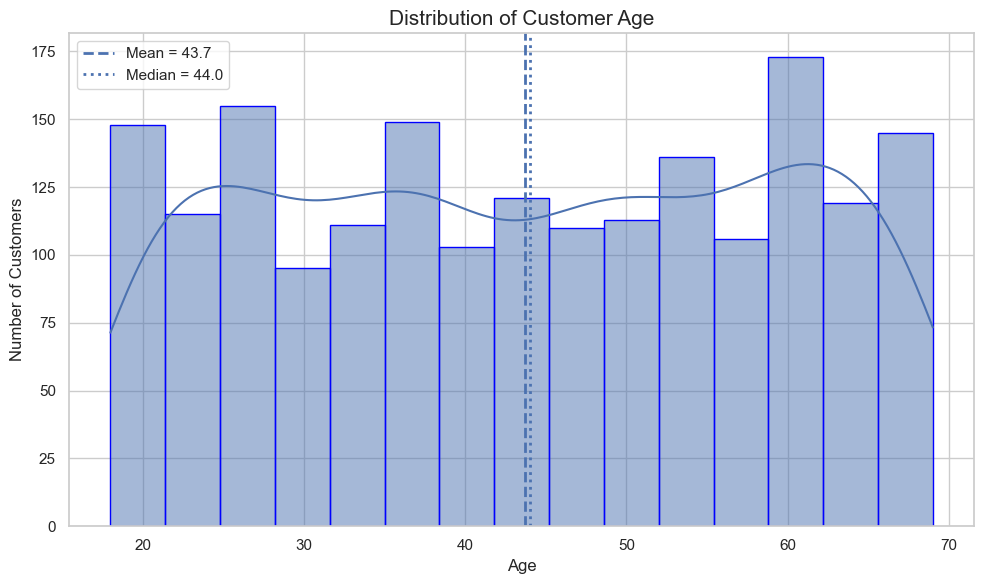

In [102]:
# Histogram of Age 
# Make sure Age is numeric
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Remove missing ages
age_data = df["Age"].dropna()

# Calculate statistics
mean_age = age_data.mean()
median_age = age_data.median()

plt.figure(figsize=(10, 6))

sns.histplot(
    age_data,
    bins=15,
    kde=True,
    edgecolor="blue")

# Mean and median lines
plt.axvline(
    mean_age,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_age:.1f}")

plt.axvline(
    median_age,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_age:.1f}")

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.legend()
plt.tight_layout()
plt.show()

2. Count Plot of Room Type
What to plot: Number of bookings for each room type
Columns: Room Type
Required: Room Type cleaned and standardized (Deluxe, Suite, Standard, Executive)
Easy explanation: Quickly tells which room type is booked the most.

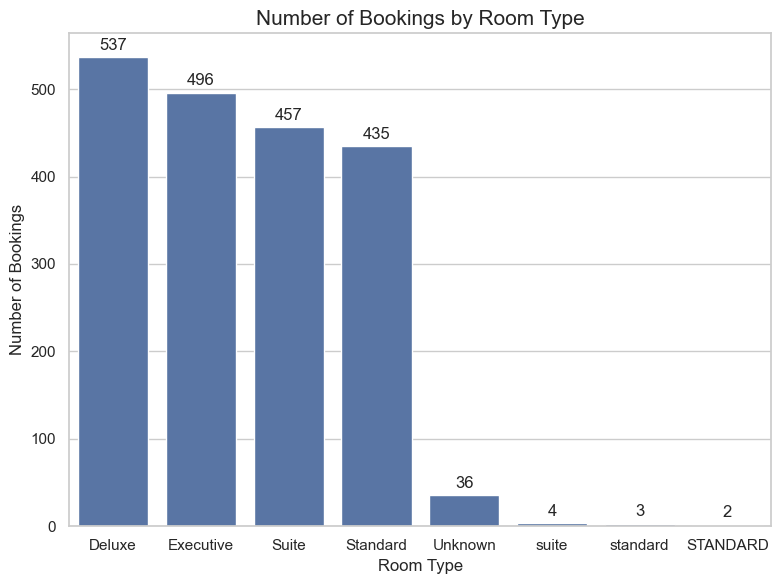

In [103]:
# Count Plot of Room Type
room_order = df["Room Type"].value_counts().index

plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df,
    x="Room Type",
    order=room_order)

# Add count labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3)

plt.title("Number of Bookings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Bookings")

plt.tight_layout()
plt.show()

3. Bar Plot of Average Final Amount by City
What to plot: Average spending (Final Amount) in each city
Columns: City, Final Amount
Required: City cleaned, Final Amount numeric
Easy explanation: Shows which city generates higher average revenue.

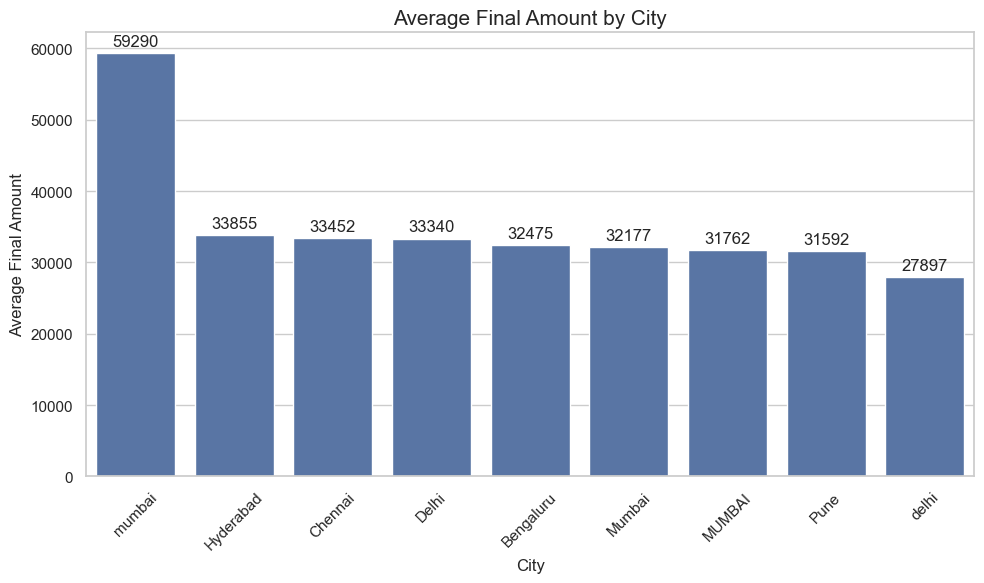

In [104]:
#Bar Plot of Average Final Amount by City
df["Final Amount"] = pd.to_numeric(
    df["Final Amount"],
    errors="coerce")

city_avg = (
    df.groupby("City", as_index=False)
    .agg(
        Average_Final_Amount=("Final Amount", "mean"),
        Number_of_Bookings=("Booking ID", "count"))
    .sort_values(
        "Average_Final_Amount",
        ascending=False))

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=city_avg,
    x="City",
    y="Average_Final_Amount")

# Display average values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3)

plt.title("Average Final Amount by City")
plt.xlabel("City")
plt.ylabel("Average Final Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. Box Plot of Room Rate by Room Type
What to plot: Spread and outliers of room rates for each room type
Columns: Room Type, Room Rate
Required: Both columns cleaned, Room Rate numeric
Easy explanation: Helps see which room type is generally expensive and if there are unusual
high/low prices.

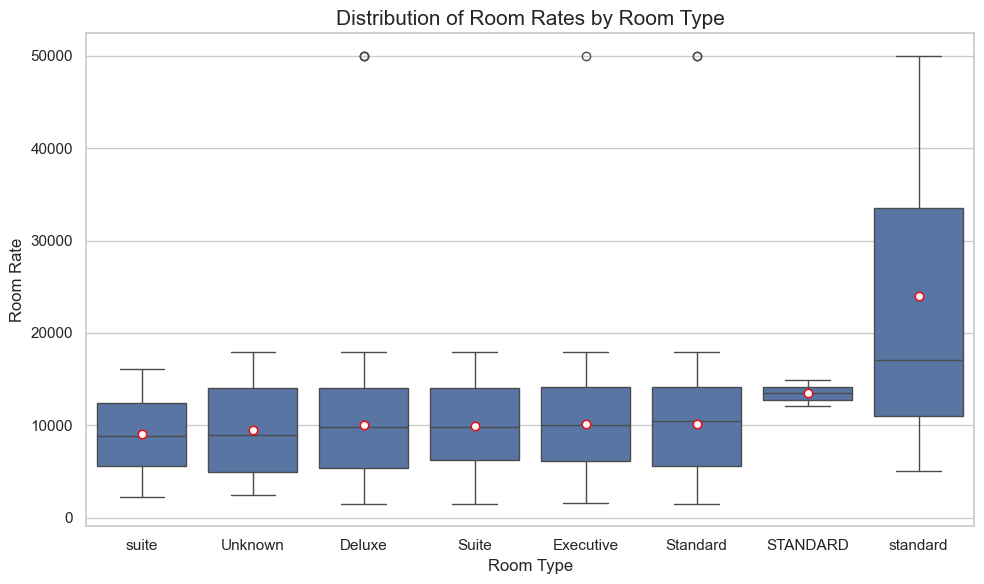

In [105]:
#Box Plot of Room Rate by Room Type
df["Room Rate"] = pd.to_numeric(
    df["Room Rate"],
    errors="coerce")

# Arrange room types according to median rate
room_order = (
    df.groupby("Room Type")["Room Rate"]
    .median()
    .sort_values()
    .index)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Room Type",
    y="Room Rate",
    order=room_order,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "red"})

plt.title("Distribution of Room Rates by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Room Rate")

plt.tight_layout()
plt.show()

5. Count Plot of Booking Channel
What to plot: How many bookings came from each channel
Columns: Booking Channel
Required: Channel names standardized (Online, Walk-in, Corporate, Travel Agent)
Easy explanation: Shows which booking method is most popular.

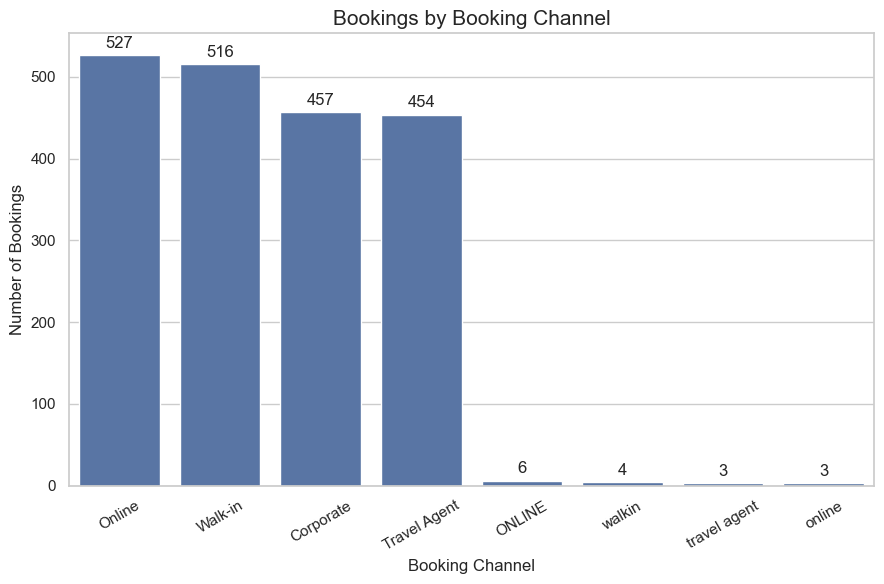

In [106]:
# Count Plot of Booking Channel
channel_order = (
    df["Booking Channel"]
    .value_counts()
    .index)

plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x="Booking Channel",
    order=channel_order)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3)

plt.title("Bookings by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


6. Histogram of Room Nights
What to plot: How long customers usually stay
Columns: Room Nights
Required: Room Nights converted to numbers (remove “3 nights”, “N/A”)
Easy explanation: Tells whether most people stay 1–2 nights or longer.

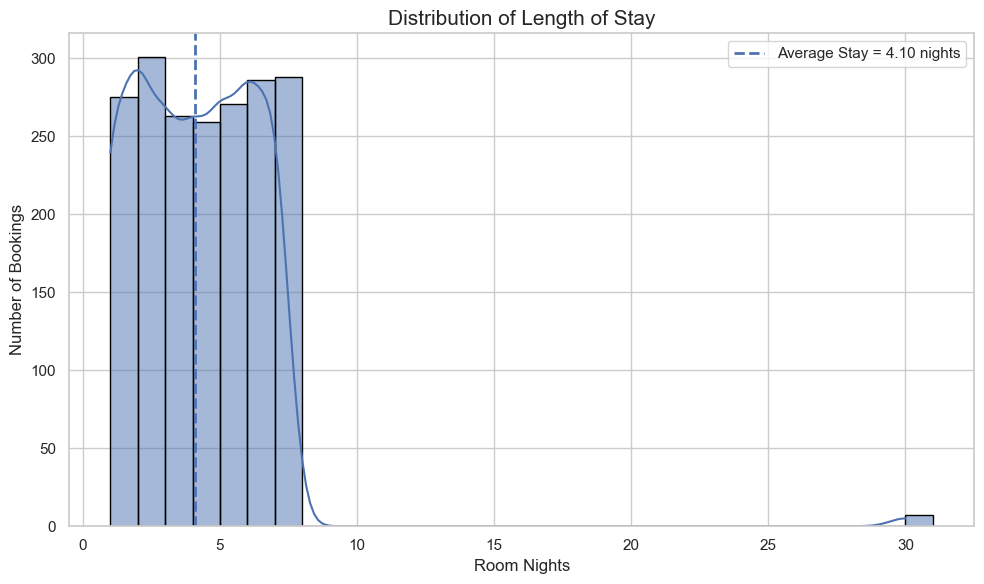

In [107]:
# Histogram of Room Nights 
df["Room Nights"] = pd.to_numeric(
    df["Room Nights"],
    errors="coerce")

room_nights = df["Room Nights"].dropna()

mean_nights = room_nights.mean()

plt.figure(figsize=(10, 6))

sns.histplot(
    room_nights,
    bins=range(
        1,
        int(room_nights.max()) + 2),
    kde=True,
    edgecolor="black")

plt.axvline(
    mean_nights,
    linestyle="--",
    linewidth=2,
    label=f"Average Stay = {mean_nights:.2f} nights")

plt.title("Distribution of Length of Stay")
plt.xlabel("Room Nights")
plt.ylabel("Number of Bookings")

plt.legend()
plt.tight_layout()
plt.show()

7. Bar Plot of Cancellation Rate by Customer Segment
What to plot: Percentage of cancelled bookings in each segment
Columns: Customer Segment, Cancelled
Required: Cancelled cleaned to 0/1, Segment standardized
Easy explanation: Shows which customer group cancels more often.

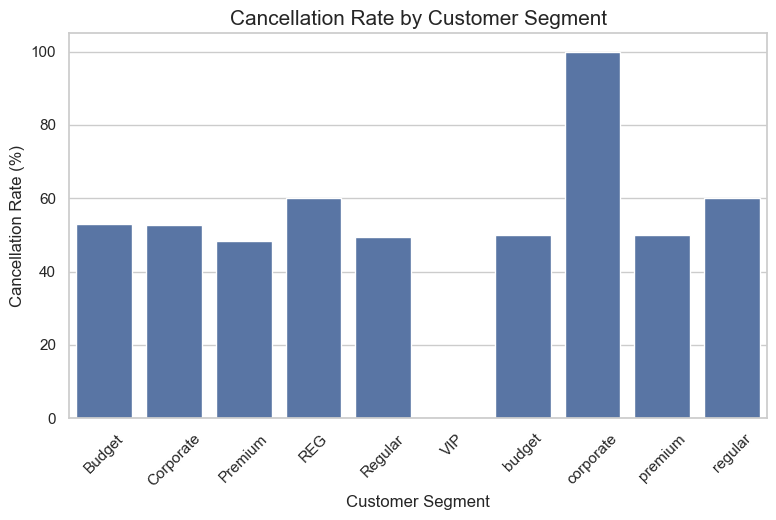

In [108]:
# Bar Plot of Cancellation Rate by Customer Segment 
cancel_rate = (
    df.groupby("Customer Segment", as_index=False)["Cancelled"]
    .mean())

cancel_rate["Cancellation Rate (%)"] = (
    cancel_rate["Cancelled"] * 100)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=cancel_rate,
    x="Customer Segment",
    y="Cancellation Rate (%)")

plt.title("Cancellation Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=45)
plt.show()

8. Box Plot of Age by Gender
What to plot: Age distribution of Male vs Female customers
Columns: Gender, Age
Required: Gender standardized (Male/Female/Other), Age numeric
Easy explanation: Checks if one gender is generally younger or older.

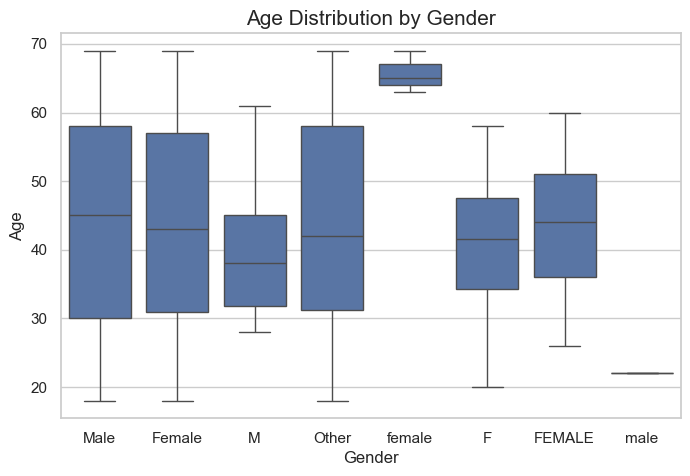

In [109]:
# Box Plot of Age by Gender
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Age")

plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

9. Count Plot of Payment Method
What to plot: Popularity of different payment methods
Columns: Payment Method
Required: Payment Method cleaned and standardized
Easy explanation: Shows whether Credit Card, UPI, Cash etc. is used more.

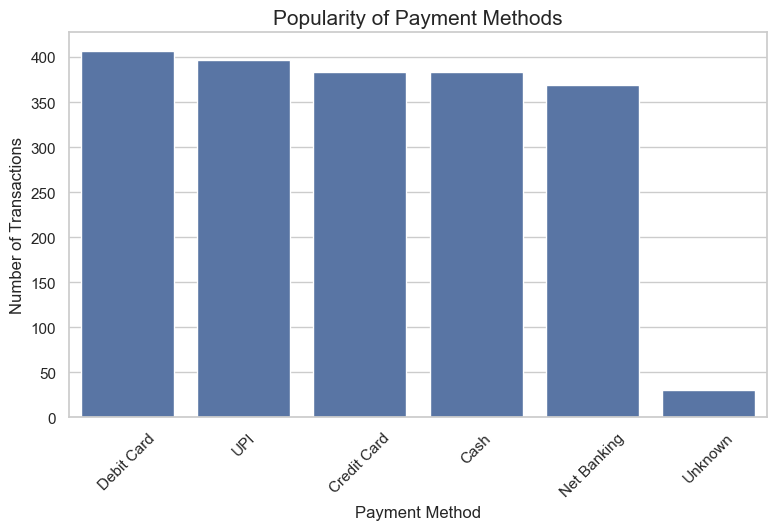

In [110]:
# Count Plot of Payment Method
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Payment Method",
    order=df["Payment Method"].value_counts().index)

plt.title("Popularity of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.show()

10. Scatter Plot of Room Rate vs Final Amount
What to plot: Relationship between room rate and total amount paid
Columns: Room Rate, Final Amount
Required: Both columns numeric and cleaned
Easy explanation: Checks if higher room rates lead to higher final bills.

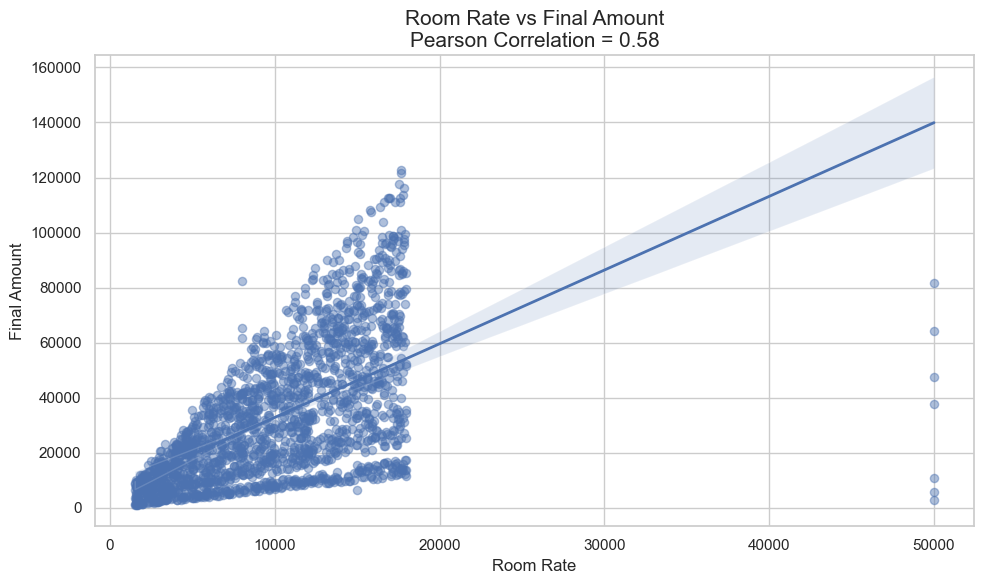

In [111]:
# Scatter Plot of Room Rate vs Final Amount
scatter_df = df[
    ["Room Rate", "Final Amount"]
].dropna()

plt.figure(figsize=(10, 6))

sns.regplot(
    data=scatter_df,
    x="Room Rate",
    y="Final Amount",
    scatter_kws={
        "alpha": 0.45,
        "s": 35
    },
    line_kws={
        "linewidth": 2
    }
)

# Calculate correlation
correlation = scatter_df[
    "Room Rate"
].corr(
    scatter_df["Final Amount"]
)

plt.title(
    f"Room Rate vs Final Amount\n"
    f"Pearson Correlation = {correlation:.2f}"
)

plt.xlabel("Room Rate")
plt.ylabel("Final Amount")

plt.tight_layout()
plt.show()

11. Violin Plot of Final Amount by Room Type
What to plot: Full distribution of spending for each room type
Columns: Room Type, Final Amount
Required: Both columns cleaned
Easy explanation: Better than box plot – shows the shape of spending (where most values
lie).

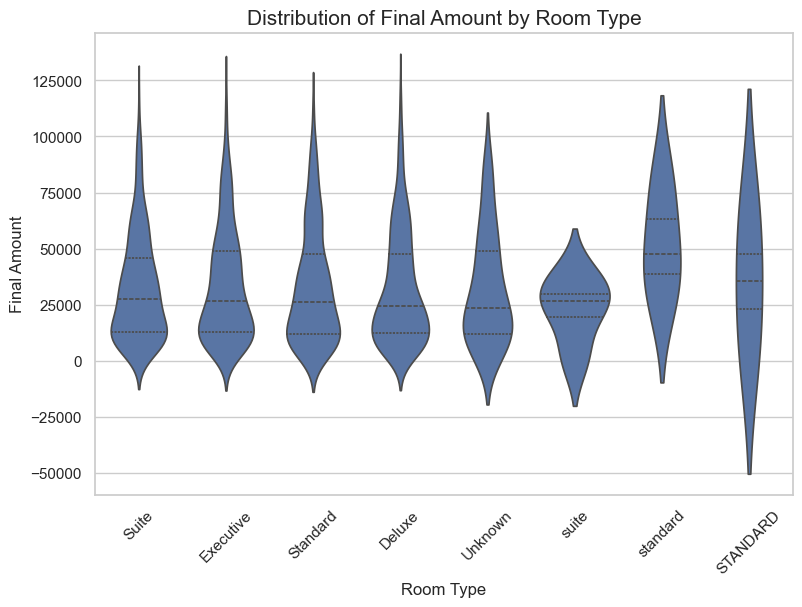

In [112]:
# Violin Plot of Final Amount by Room Type
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x="Room Type",
    y="Final Amount",
    inner="quartile")

plt.title("Distribution of Final Amount by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Final Amount")

plt.xticks(rotation=45)
plt.show()

12. Bar Plot of Average Discount % by Booking Channel
What to plot: Which channel gives higher average discount
Columns: Booking Channel, Discount %
Required: Discount % converted to numbers (0–100)
Easy explanation: Helps understand discount strategy across channels.

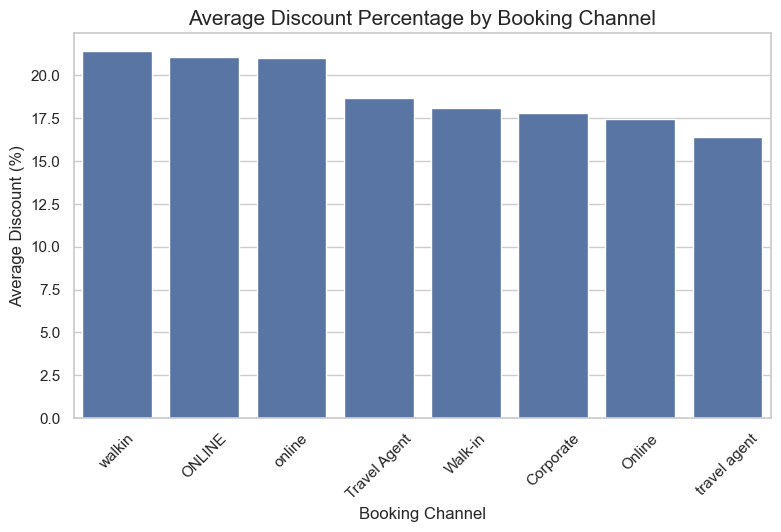

In [113]:
# Bar Plot of Average Discount % by Booking Channel 
discount_avg = (
    df.groupby("Booking Channel", as_index=False)["Discount %"]
    .mean()
    .sort_values("Discount %", ascending=False))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=discount_avg,
    x="Booking Channel",
    y="Discount %")

plt.title("Average Discount Percentage by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Average Discount (%)")

plt.xticks(rotation=45)
plt.show()

13. Histogram of Rating
What to plot: How customers rated their stay
Columns: Rating
Required: Rating cleaned (only 1 to 5 values)
Easy explanation: Shows whether most ratings are high, low, or mixed.

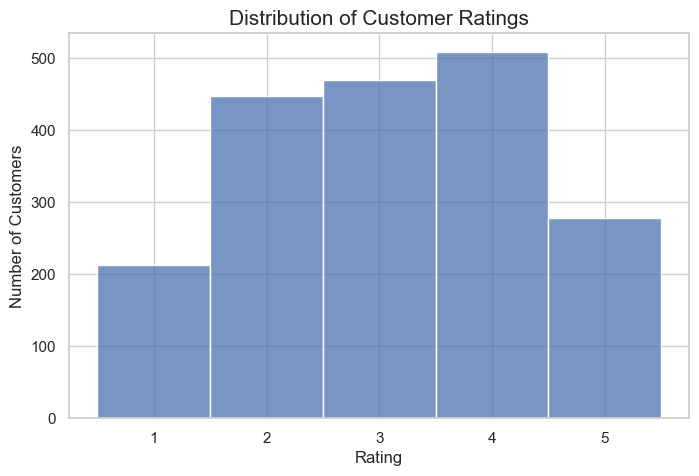

In [114]:
# Histogram of Rating
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Rating",
    bins=5,
    discrete=True)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

14. Count Plot of Is Member
What to plot: How many members vs non-members
Columns: Is Member
Required: Converted to Yes/No or 1/0
Easy explanation: Quick view of member vs non-member ratio.

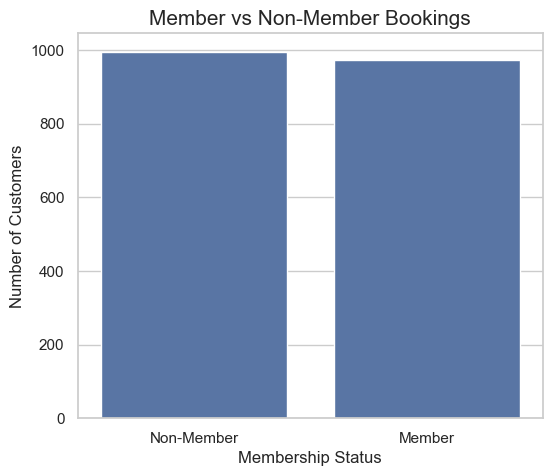

In [115]:
# Count Plot of Is Member
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Is Member")

plt.title("Member vs Non-Member Bookings")
plt.xlabel("Membership Status")
plt.ylabel("Number of Customers")

plt.xticks(
    ticks=[0, 1],
    labels=["Non-Member", "Member"])

plt.show()

15. Box Plot of Profit by City
What to plot: Profit distribution across different cities
Columns: City, Profit
Required: City cleaned, Profit numeric
Easy explanation: Identifies which city is more profitable and if there are extreme
profits/losses.

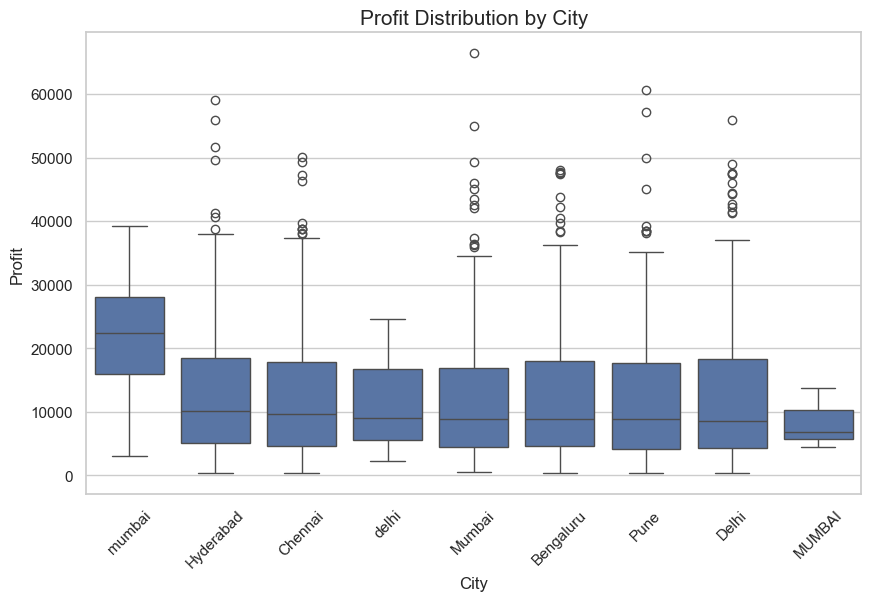

In [116]:
# Box  Plot of Profit by City
city_order = (
    df.groupby("City")["Profit"]
    .median()
    .sort_values(ascending=False)
    .index)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="City",
    y="Profit",
    order=city_order)

plt.title("Profit Distribution by City")
plt.xlabel("City")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.show()

16. Bar Plot of Average Guests by Room Type
What to plot: Average number of guests staying in each room type
Columns: Room Type, Guests
Required: Both cleaned, Guests numeric
Easy explanation: Shows whether Suite or Deluxe rooms are used by larger groups.

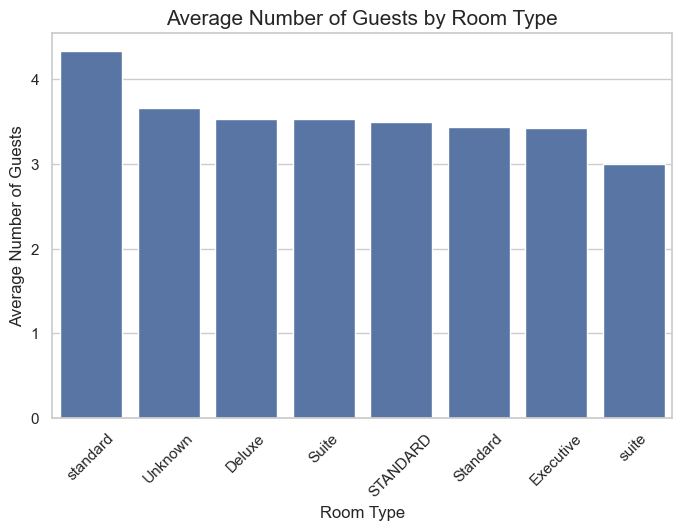

In [117]:
#Bar Plot of Average Guests by Room
avg_guests = (
    df.groupby("Room Type", as_index=False)["Guests"]
    .mean()
    .sort_values("Guests", ascending=False))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_guests,
    x="Room Type",
    y="Guests")

plt.title("Average Number of Guests by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Number of Guests")

plt.xticks(rotation=45)
plt.show()

17. KDE Plot (Density Plot) of Age
What to plot: Smooth distribution of customer ages
Columns: Age
Required: Age numeric and cleaned
Easy explanation: Similar to histogram but smoother – shows the overall age pattern clearly.

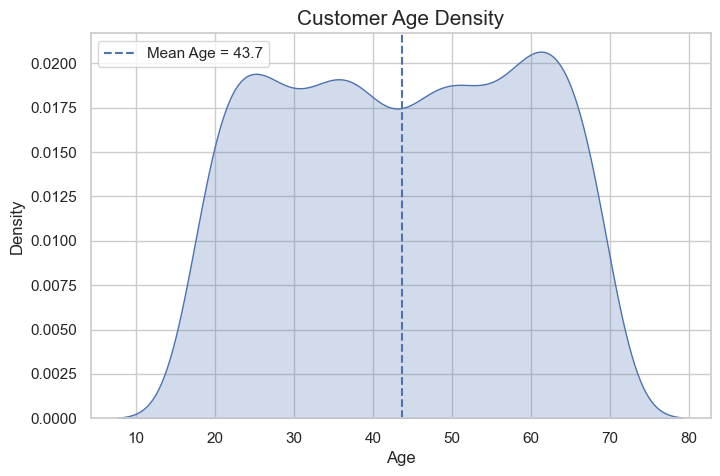

In [118]:
# KDE Plot (Density Plot) of Age
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x="Age",
    fill=True,
    bw_adjust=1)

plt.axvline(
    df["Age"].mean(),
    linestyle="--",
    label=f"Mean Age = {df['Age'].mean():.1f}")

plt.title("Customer Age Density")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()

plt.show()

18. Heatmap of Correlation between Numeric Columns
What to plot: Relationship strength between numbers like Age, Room Rate, Final Amount,
Profit, Discount %
Columns: Select numeric columns only
Required: All selected columns must be numeric and cleaned
Easy explanation: Quickly shows which factors move together (positive or negative relation).

In [119]:
numeric_columns = [
    "Age",
    "Room Nights",
    "Room Rate",
    "Discount %",
    "Rating",
    "Guests",
    "Gross Amount",
    "Discount Amount",
    "Final Amount",
    "Hotel Cost",
    "Profit"]

correlation_matrix = df[numeric_columns].corr()

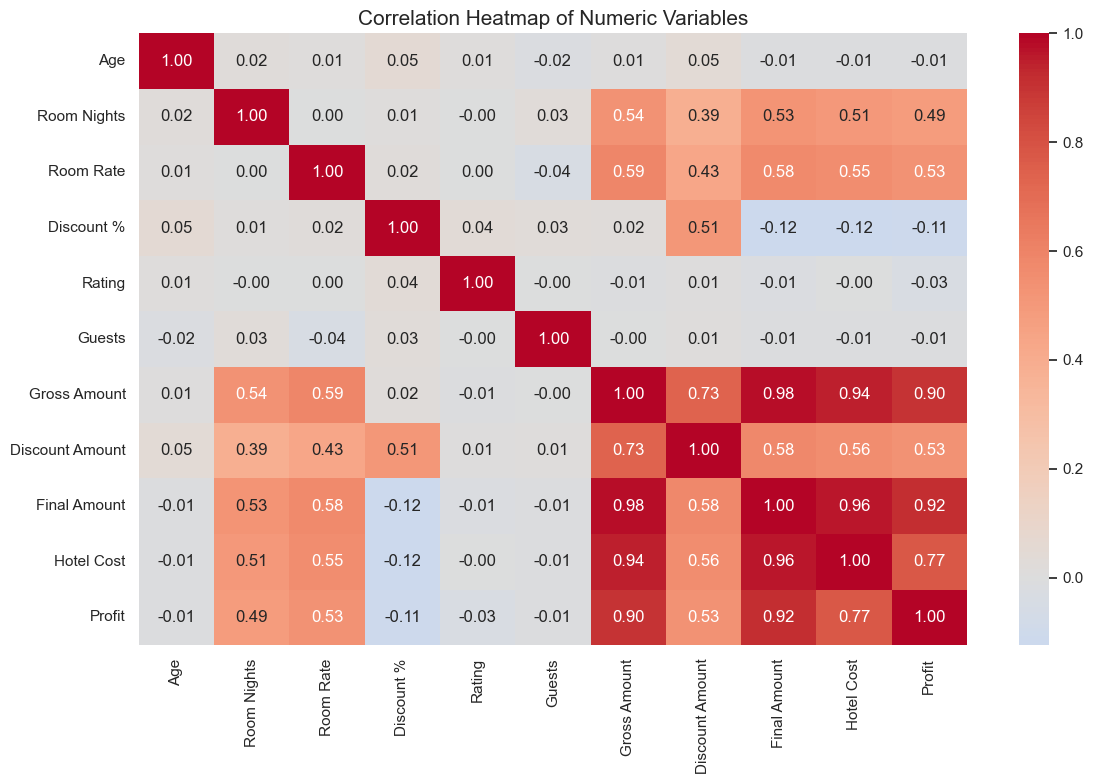

In [120]:
# Heatmap of Correlation between Numeric Columns 
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numeric Variables")

plt.tight_layout()
plt.show()

19. Count Plot of Gender with Hue as Customer Segment
What to plot: Gender distribution inside each customer segment
Columns: Gender, Customer Segment
Required: Both columns cleaned and standardized
Easy explanation: Shows if Premium segment has more males or females, etc.

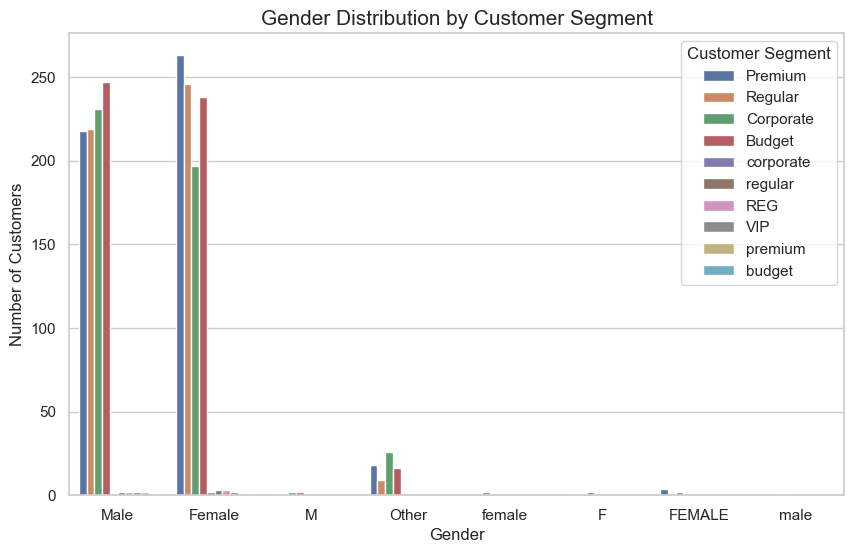

In [121]:
# Count Plot of Gender with Hue as Customer Segment 
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Gender",
    hue="Customer Segment")

plt.title("Gender Distribution by Customer Segment")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(
    title="Customer Segment")

plt.show()


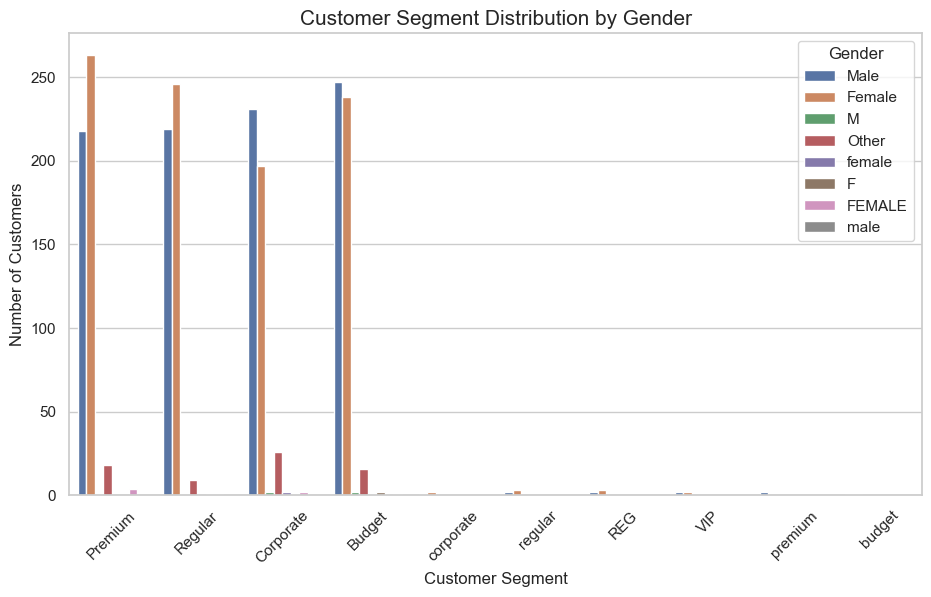

In [122]:
plt.figure(figsize=(11, 6))

sns.countplot(
    data=df,
    x="Customer Segment",
    hue="Gender"
)

plt.title("Customer Segment Distribution by Gender")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.legend(title="Gender")

plt.show()

20. Bar Plot of Total Gross Amount by Month (from Booking Date)
What to plot: Total revenue generated in each month
Columns: Booking Date, Gross Amount
Required: Booking Date converted to proper date format, then extract month
Easy explanation: Shows which months are busiest in terms of revenue.

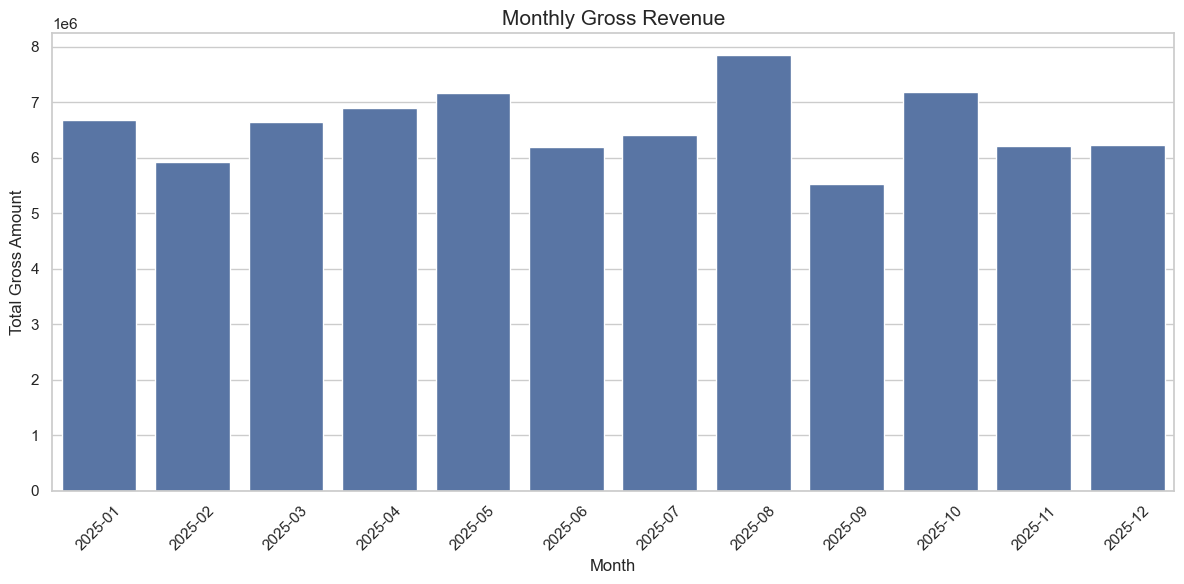

In [123]:
# Bar Plot of Total Gross Amount by Month (from Booking Date) 
df["Booking Date"] = pd.to_datetime(
    df["Booking Date"],
    errors="coerce")

df["Year_Month"] = (
    df["Booking Date"]
    .dt.to_period("M")
    .astype(str))

monthly_revenue = (
    df.groupby("Year_Month", as_index=False)["Gross Amount"]
    .sum())

plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_revenue,
    x="Year_Month",
    y="Gross Amount")

plt.title("Monthly Gross Revenue")
plt.xlabel("Month")
plt.ylabel("Total Gross Amount")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()